# Chapter 12 - Model Evaluation

Training a model is only the first part of a Machine Learning project.
After training, we need to ask a more important question: how well is the model performing?

In this chapter, we will evaluate models with metrics for two kind of tasks:

- classification metrics for category predictions, such as placement or no placement
- regression metrics for numeric predictions, such as price or delay

The goal is to understand what each metric measures and when it is more useful than a simple accuracy number.

## Step 1 - Load the Placement Dataset

We will start with the student placement dataset.
The model will use IQ and CGPA to predict whether a student was placed.

In [1]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

In [2]:
# import the students data
url = "https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch12/students.csv"
df = pd.read_csv(url)

print("Dataset preview:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

Dataset preview:
           IQ      CGPA  Placed
0  116.521863  7.839804       1
1  111.114991  7.230805       1
2  109.839861  7.253657       1
3   99.772056  5.960763       0
4  111.693979  9.576941       1

Dataset shape:
(100, 3)


The preview confirms that the dataset has two input features `IQ` and `CGPA` and one target column `Placed`.

Since Placed is already encoded as 0 or 1, the data is ready for Logistic Regression.

## Step 2 - Train a Classification Model

Accuracy, precision, recall, F1 score, and ROC-AUC - all need model predictions.

First we split the data, train Logistic Regression, and create predictions on the test set.

In [3]:
# Separate the input features from the target variable.
X = df[["IQ", "CGPA"]]
y = df["Placed"]

print("Feature preview before splitting:")
print(X.head())

print("\nTarget preview before splitting:")
print(y.head())

Feature preview before splitting:
           IQ      CGPA
0  116.521863  7.839804
1  111.114991  7.230805
2  109.839861  7.253657
3   99.772056  5.960763
4  111.693979  9.576941

Target preview before splitting:
0    1
1    1
2    1
3    0
4    1
Name: Placed, dtype: int64


In [4]:
# Keep part of the data unseen during training so that evaluation is honest.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("\nClass balance in the test set:")
print(y_test.value_counts().sort_index())

Training rows: 80
Testing rows: 20

Class balance in the test set:
Placed
0     7
1    13
Name: count, dtype: int64


In [5]:
# Train the Logistic Regression model on the training rows only.
model = LogisticRegression()
model.fit(X_train, y_train)

# These are hard class predictions: each test row becomes either 0 or 1.
y_pred = model.predict(X_test)

comparison = X_test.copy()
comparison["Actual Placed"] = y_test.values
comparison["Predicted Placed"] = y_pred

print("Actual vs predicted placement for a few test rows:")
print(comparison.head(10))

Actual vs predicted placement for a few test rows:
            IQ      CGPA  Actual Placed  Predicted Placed
83  130.727326  6.875640              1                 1
53  125.510703  8.128214              1                 1
70   90.048670  7.120132              0                 0
45  127.157197  8.865010              1                 1
44  109.250244  7.843512              0                 1
39  123.255592  7.736650              1                 1
22  103.077949  8.057094              0                 0
80  112.164269  8.920070              1                 1
10   97.510389  7.062245              0                 0
0   116.521863  7.839804              1                 1


This comparison table is the base for the classification metrics.
Each metric looks at the same predictions, but each one asks a different question.

## Step 3 - Accuracy

Accuracy measures the proportion of total predictions that the model got right.

It is easy to understand, but it treats every type of mistake as equally important.

In [6]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Correct predictions: {(y_test.values == y_pred).sum()} out of {len(y_test)}")

Accuracy: 0.950
Correct predictions: 19 out of 20


Accuracy gives a quick first score.

But accuracy alone can be misleading, especially when the classes are imbalanced or when one type of error is more costly.

## Step 4 - Confusion Matrix

The confusion matrix shows what kind of mistakes the model made.

This matters because a false positive and a false negative can have very different real-world costs.

In [7]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Placed (0)", "Actual Placed (1)"],
    columns=["Predicted Not Placed (0)", "Predicted Placed (1)"],
)

print("Confusion matrix:")
print(cm_df)

# Read the four cells so we can interpret the model clearly.
tn, fp, fn, tp = cm.ravel()
print("\nTrue negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

Confusion matrix:
                       Predicted Not Placed (0)  Predicted Placed (1)
Actual Not Placed (0)                         6                     1
Actual Placed (1)                             0                    13

True negatives: 6
False positives: 1
False negatives: 0
True positives: 13


True positives and true negatives are correct predictions.

False positives and false negatives are mistakes, and the confusion matrix tells us which type of mistake happened.

## Step 5 - Precision, Recall, and F1 Score

Precision asks: when the model predicts the positive class, how often is it correct?

Recall asks: out of all actual positive cases, how many did the model find?

F1 score combines precision and recall into one balanced score.

In [8]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metric_table = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Value": [accuracy, precision, recall, f1],
        "Question answered": [
            "How many total predictions were correct?",
            "When the model predicted placed, how often was it right?",
            "How many actually placed students did the model find?",
            "How balanced are precision and recall together?",
        ],
    }
)

print(metric_table.to_string(index=False))

   Metric    Value                                        Question answered
 Accuracy 0.950000                 How many total predictions were correct?
Precision 0.928571 When the model predicted placed, how often was it right?
   Recall 1.000000    How many actually placed students did the model find?
 F1 Score 0.962963          How balanced are precision and recall together?


Precision becomes important when false positives are costly.

Recall becomes important when missing a positive case is costly.

F1 score is useful when both sides matter and we want one combined number.

## Step 6 - ROC-AUC Curve

The earlier metrics use hard predictions: 0 or 1.

Logistic Regression can also give probabilities, and a threshold converts those probabilities into classes.

ROC-AUC evaluates performance across many thresholds instead of using only one fixed cutoff.

In [9]:
# predict_proba returns one probability for class 0 and one probability for class 1.
# We select the probability of class 1 because Placed is the positive class.
y_pred_proba = model.predict_proba(X_test)[:, 1]

probability_preview = comparison.copy()
probability_preview["Predicted Probability of Placed"] = y_pred_proba

print("Prediction probabilities before applying any threshold:")
print(probability_preview.head(10))

Prediction probabilities before applying any threshold:
            IQ      CGPA  Actual Placed  Predicted Placed  \
83  130.727326  6.875640              1                 1   
53  125.510703  8.128214              1                 1   
70   90.048670  7.120132              0                 0   
45  127.157197  8.865010              1                 1   
44  109.250244  7.843512              0                 1   
39  123.255592  7.736650              1                 1   
22  103.077949  8.057094              0                 0   
80  112.164269  8.920070              1                 1   
10   97.510389  7.062245              0                 0   
0   116.521863  7.839804              1                 1   

    Predicted Probability of Placed  
83                     1.000000e+00  
53                     9.999999e-01  
70                     2.294639e-08  
45                     1.000000e+00  
44                     7.247786e-01  
39                     9.999994e-01  
22    

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

roc_preview = pd.DataFrame(
    {
        "Threshold": thresholds,
        "False Positive Rate": fpr,
        "True Positive Rate": tpr,
    }
)

print(f"ROC-AUC Score: {auc_score:.3f}")
print("\nFirst ROC threshold points:")
print(roc_preview.head())

ROC-AUC Score: 1.000

First ROC threshold points:
      Threshold  False Positive Rate  True Positive Rate
0           inf                  0.0            0.000000
1  1.000000e+00                  0.0            0.076923
2  9.742377e-01                  0.0            1.000000
3  2.294639e-08                  1.0            1.000000


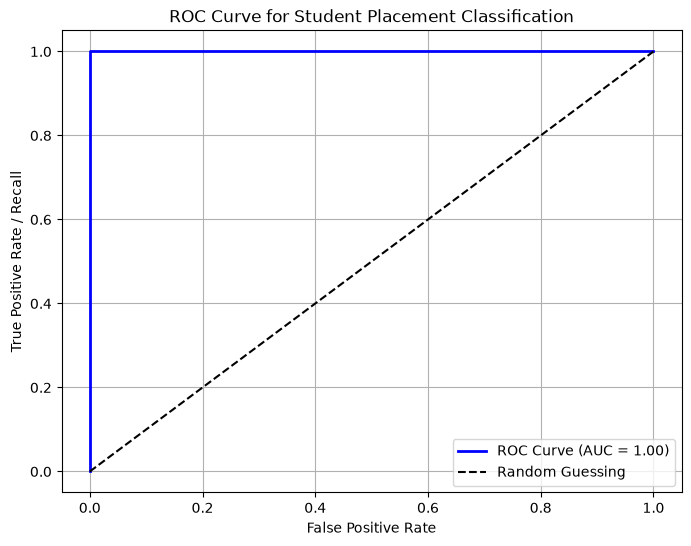

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guessing")
plt.title("ROC Curve for Student Placement Classification")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

A curve closer to the top-left corner means stronger classification performance.

The diagonal line is random guessing; a useful model should stay above that line.

## Step 7 - Regression Metrics

Classification metrics do not apply when the target is a continuous number.
For regression, we measure the size of prediction errors.

We will use a small house-price example to explain - MAE, MSE, RMSE, and R2.

In [12]:
# price values are in dollars
regression_results = pd.DataFrame(
    {
        "House": [1, 2, 3, 4, 5],
        "Actual Price": [200, 150, 100, 250, 180],
        "Predicted Price": [210, 130, 90, 240, 185],
    }
)

print("Regression predictions before calculating errors:")
print(regression_results)

Regression predictions before calculating errors:
   House  Actual Price  Predicted Price
0      1           200              210
1      2           150              130
2      3           100               90
3      4           250              240
4      5           180              185


In [13]:
regression_results["Error"] = regression_results["Actual Price"] - regression_results["Predicted Price"]
regression_results["Absolute Error"] = regression_results["Error"].abs()
regression_results["Squared Error"] = regression_results["Error"] ** 2

print("Regression predictions after calculating errors:")
print(regression_results)

Regression predictions after calculating errors:
   House  Actual Price  Predicted Price  Error  Absolute Error  Squared Error
0      1           200              210    -10              10            100
1      2           150              130     20              20            400
2      3           100               90     10              10            100
3      4           250              240     10              10            100
4      5           180              185     -5               5             25


The before table shows only actual and predicted values.

The after table makes the error visible, which helps us understand what each regression metric is measuring.

## Step 8 - MAE, MSE, and RMSE

MAE gives the average absolute error in the same unit as the target.

MSE squares errors, so larger mistakes receive a heavier penalty.

RMSE takes the square root of MSE and brings the metric back to the original unit.

In [14]:
y_actual_reg = regression_results["Actual Price"]
y_pred_reg = regression_results["Predicted Price"]

mae = mean_absolute_error(y_actual_reg, y_pred_reg)
mse = mean_squared_error(y_actual_reg, y_pred_reg)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Mean Absolute Error: 11.00
Mean Squared Error: 145.00
Root Mean Squared Error: 12.04


MAE is the easiest to explain because it is in the same unit as the target.

MSE and RMSE are more sensitive to large errors, so they are useful when large mistakes need extra attention.

## Step 9 - R2 Score

R2 compares the model against a very simple baseline: always predicting the average target value.

- If R² = 1, our model predicts the data perfectly—every point lands exactly where it should.
- If R² = 0, our model is no better than guessing the average every time.
- If R² < 0, our model is actually doing worse than the average guess—it's introducing noise instead of reducing it.

In [15]:
r2 = r2_score(y_actual_reg, y_pred_reg)

baseline_prediction = np.repeat(y_actual_reg.mean(), len(y_actual_reg))
baseline_mae = mean_absolute_error(y_actual_reg, baseline_prediction)
model_mae = mean_absolute_error(y_actual_reg, y_pred_reg)

print(f"R2 Score: {r2:.3f}")
print(f"Model MAE: {model_mae:.2f}")
print(f"Average-baseline MAE: {baseline_mae:.2f}")

R2 Score: 0.942
Model MAE: 11.00
Average-baseline MAE: 40.80


R2 adds context to the error metrics.

Instead of only telling us the size of the errors, it tells us whether the model is better than a simple average-based guess.

## Chapter Recap

In this chapter, we evaluated classification and regression models with different metrics.

- Accuracy is a quick overall score, but it can hide important error types.
- A confusion matrix separates true positives, true negatives, false positives, and false negatives.
- Precision focuses on the reliability of positive predictions.
- Recall focuses on finding the actual positive cases.
- F1 score balances precision and recall.
- ROC-AUC studies performance across many probability thresholds.
- MAE, MSE, RMSE, and R2 evaluate numeric regression predictions.